In [1]:
import matplotlib.pyplot as plt
import open3d as o3d
import numpy as np
import os

import pyFM.spectral as spectral
from pyFM.mesh import TriMesh

from tqdm.auto import tqdm
import meshplot as mp

def double_plot_o3d(myMesh1,myMesh2,cmap1=None,cmap2=None):
    vertlist_1 = np.asarray(myMesh1.vertices)
    facelist_1 = np.asarray(myMesh1.triangles)

    vertlist_2 = np.asarray(myMesh2.vertices)
    facelist_2 = np.asarray(myMesh2.triangles)
    
    d = mp.subplot(vertlist_1, facelist_1, c=cmap1, s=[2, 2, 0])
    mp.subplot(vertlist_2, facelist_2, c=cmap2, s=[2, 2, 1], data=d)

def plot_mesh(myMesh,cmap=None):
    mp.plot(myMesh.vertlist, myMesh.facelist,c=cmap)
    
def double_plot(myMesh1,myMesh2,cmap1=None,cmap2=None):
    d = mp.subplot(myMesh1.vertlist, myMesh1.facelist, c=cmap1, s=[2, 2, 0])
    mp.subplot(myMesh2.vertlist, myMesh2.facelist, c=cmap2, s=[2, 2, 1], data=d)

def visu(vertices):
    min_coord,max_coord = np.min(vertices,axis=0,keepdims=True),np.max(vertices,axis=0,keepdims=True)
    cmap = (vertices-min_coord)/(max_coord-min_coord)
    return cmap

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


## 1. Data Pre-Processing ____________________________________
(need to change this back to just doing it with o3d rather than TriMesh)
1. Load Meshes
2. Generate Intial Point to Point Maps 
3. Convert to Functional Maps

In [2]:
def clean_mesh(mesh):

    # Remove duplicate vertices
    mesh.remove_duplicated_vertices()
    # Remove degenerate triangles
    mesh.remove_degenerate_triangles()
    # Remove unreferenced vertices
    mesh.remove_unreferenced_vertices()

    # triangle_clusters, cluster_n_triangles, cluster_areas = mesh.cluster_connected_triangles()

    # # Find the index of the largest cluster (by area or by number of triangles)
    # largest_cluster_index = np.argmax(cluster_areas)

    # # Create a mask for triangles belonging to the largest cluster
    # mask = (np.asarray(triangle_clusters) == largest_cluster_index)

    # # Extract the corresponding triangles and vertices
    # new_triangles = np.asarray(mesh.triangles)[mask]
    # new_vertices = np.asarray(mesh.vertices)

    # # Build a new mesh
    # cleaned_mesh = o3d.geometry.TriangleMesh(
    #     o3d.utility.Vector3dVector(new_vertices),
    #     o3d.utility.Vector3iVector(new_triangles)
    # )

    # # Optionally, remove unreferenced vertices
    # cleaned_mesh = cleaned_mesh.remove_unreferenced_vertices()
    return mesh

# path = os.path.abspath('../simulation/meshes_dancer')
path = os.path.abspath('renders_small_dataset')

start_frame = 1
end_frame = 10
frames = [str(i).zfill(4) for i in range(start_frame, end_frame + 1)]

# load meshes
# mesh_list_o3d = [o3d.io.read_triangle_mesh(f'{path}/frame_{frame}.ply') for frame in tqdm(frames)]
mesh_list_o3d = [o3d.io.read_triangle_mesh(f'{path}/render_frame_{frame}.ply') for frame in tqdm(frames)]

# ind_1 = 0
# ind_2 = 8

# double_plot_o3d(mesh_list_o3d[ind_1], mesh_list_o3d[ind_2])

# mesh_2 = clean_mesh(mesh_list_o3d[ind_2])
# double_plot_o3d(mesh_list_o3d[ind_1], mesh_2)

mesh_list = []
count = 0
for mesh in tqdm(mesh_list_o3d):

    cleanMesh = clean_mesh(mesh)
    # count += 1
    # print(count)

    # mesh_simplified = mesh.simplify_quadric_decimation(target_number_of_triangles=1000 * 2)  # ~2 faces per vertex
    verts, faces = np.asarray(cleanMesh.vertices), np.asarray(cleanMesh.triangles)
    
    # Create a TriMesh
    mesh_pyfm = TriMesh(verts, faces, area_normalize=True, center=True)
    mesh_pyfm.process(k=150, intrinsic=True) # why is this section so hard to process!!!!
    mesh_list.append(mesh_pyfm)


  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

### Landmark Based Intial Maps - Not Working

In [1]:
def keypoints_to_spheres(keypoints):
    spheres = o3d.geometry.TriangleMesh()
    for keypoint in keypoints.points:
        sphere = o3d.geometry.TriangleMesh.create_sphere(radius=0.005)
        sphere.translate(keypoint)
        spheres += sphere
    spheres.paint_uniform_color([1.0, 0.75, 0.0])
    return spheres

def landmark_based_p2p_map(verts_i, verts_j):
    # Create point clouds
    pcd_i = o3d.geometry.PointCloud()
    pcd_j = o3d.geometry.PointCloud()
    pcd_i.points = o3d.utility.Vector3dVector(verts_i)
    pcd_j.points = o3d.utility.Vector3dVector(verts_j)

    # Estimate normals (needed for most 3D feature descriptors)
    pcd_i.estimate_normals()
    pcd_j.estimate_normals()

    # Detect ISS keypoints
    key_i = o3d.geometry.keypoint.compute_iss_keypoints(pcd_i)
    key_j = o3d.geometry.keypoint.compute_iss_keypoints(pcd_j)

    print(key_i.shape)

    # # Compute SHOT descriptors at those keypoints
    # shot_i = compute_shot_descriptors(pcd_i, key_i)
    # shot_j = compute_shot_descriptors(pcd_j, key_j)

    #pcd_i.compute_vertex_normals()
    pcd_i.paint_uniform_color([0.5, 0.5, 0.5])
    o3d.visualization.draw_geometries([keypoints_to_spheres(key_i), pcd_i])


    # # Convert to NumPy arrays
    # desc_i = np.asarray(key_i.data).T
    # desc_j = np.asarray(key_j.data).T

    # # Build KDTree on target descriptors
    # kdtree = o3d.geometry.KDTreeFlann(o3d.pipelines.registration.Feature())
    # kdtree.set_feature(key_j)

    # # Match descriptors (1-NN)
    # p2p_ji = []
    # for feat in desc_i:
    #     [_, idx, _] = kdtree.search_knn_vector_xd(o3d.utility.DoubleVector(feat), 1)
    #     p2p_ji.append(idx[0])

    # return np.array(p2p_ji)

    # Compute FPFH descriptors for those keypoints
    radius_normal = 0.05
    radius_feature = 0.1

    pcd_i_tree = o3d.geometry.KDTreeFlann(pcd_i)
    pcd_j_tree = o3d.geometry.KDTreeFlann(pcd_j)

    fpfh_i = o3d.pipelines.registration.compute_fpfh_feature(
        key_i,
        o3d.geometry.KDTreeSearchParamHybrid(radius=radius_feature, max_nn=100))
    fpfh_j = o3d.pipelines.registration.compute_fpfh_feature(
        key_j,
        o3d.geometry.KDTreeSearchParamHybrid(radius=radius_feature, max_nn=100))

    # Match keypoints using descriptor nearest neighbour
    fpfh_i_np = np.asarray(fpfh_i.data).T
    fpfh_j_np = np.asarray(fpfh_j.data).T

    kdtree = o3d.geometry.KDTreeFlann(fpfh_j)
    p2p_ji = []
    for feat in fpfh_i_np:
        [_, idx, _] = kdtree.search_knn_vector_xd(o3d.utility.DoubleVector(feat), 1)
        p2p_ji.append(idx[0])

    return np.array(p2p_ji), np.asarray(key_i.points), np.asarray(key_j.points)

### Regular CLosest Point Method 

In [4]:
def initial_p2p_map(verts_i, verts_j):

    pcd_j = o3d.geometry.PointCloud() # create pointcloud
    pcd_j.points = o3d.utility.Vector3dVector(verts_j) # assign verts with normals to cloud

    kdtree = o3d.geometry.KDTreeFlann(pcd_j)
    
    p2p_ji = []
    for vert_i in verts_i:
        [_, idx, _] = kdtree.search_knn_vector_3d(vert_i, 1)
        p2p_ji.append(idx[0])

    p2p_ji = np.array(p2p_ji)
    return p2p_ji

# Test Display
mesh_1 = mesh_list_o3d[9]; mesh_2 = mesh_list_o3d[4]
verts_1 = np.asarray(mesh_1.vertices)
verts_2 = np.asarray(mesh_2.vertices)

p2p_map = initial_p2p_map(verts_2,verts_1)
cmap_1 = visu(verts_1)
cmap_2 = cmap_1[p2p_map]

print(verts_1.shape)
print(verts_2.shape)
print(p2p_map.shape)

double_plot_o3d(mesh_1, mesh_2, cmap_1,cmap_2)

(39739, 3)
(41205, 3)
(41205,)


## Regular Maps 

In [ ]:
K = 30 # intial dimensions
maps_dict = {}
n_meshes = len(mesh_list)

for i in tqdm(range(n_meshes)):
    for j in range(n_meshes):
        if i == j: 
            continue # skip self-maps

        mesh_i, mesh_j = mesh_list[i], mesh_list[j]

        verts_i, verts_j = np.asarray(mesh_i.vertices), np.asarray(mesh_j.vertices)
        p2p_ji = initial_p2p_map(verts_j, verts_i)

        # Convert to functional map
        FM_ij = spectral.mesh_p2p_to_FM(p2p_ji, mesh_i, mesh_j, dims=K)
    
        # Populate the dictionary
        maps_dict[(i, j)] = FM_ij

  0%|          | 0/10 [00:00<?, ?it/s]

## Optimisation?

In [ ]:
def optimised_dict(mesh_list, interval_size=2, bidirectional=True, K=30):
    optimised_dict = {}
    n_meshes = len(mesh_list)

    for i in tqdm(range(n_meshes)):
        source_mesh = mesh_list[i]

        for k in range(1, interval_size + 1):
            j = i + k 
            if j < n_meshes:
                target_mesh = mesh_list[j]

                # Compute inital maps
                verts_i, verts_j = np.asarray(source_mesh.vertices), np.asarray(target_mesh.vertices)
                p2p_ji = initial_p2p_map(verts_j, verts_i)

                # Convert to functional maps
                FM_ij = spectral.mesh_p2p_to_FM(p2p_ji, source_mesh, target_mesh, dims=K)
                optimised_dict[(i, j)] = FM_ij

                if bidirectional:
                    p2p_ij = initial_p2p_map(verts_i, verts_j)
                    FM_ji = spectral.mesh_p2p_to_FM(p2p_ij, target_mesh, source_mesh, dims=K)
                    optimised_dict[(j, i)] = FM_ji
    
    print(optimised_dict.keys())

    for i in tqdm(range(n_meshes)):
        for j in range(n_meshes):
            if i == j or (i, j) in optimised_dict:
                continue


            # Look for a valid intermediate step
            for step in range(i + 1, j):
                if (i, step) in optimised_dict and (step, j) in optimised_dict:
                    FM_ij = optimised_dict[(i, step)] @ optimised_dict[(step, j)]
                    optimised_dict[(i, j)] = FM_ij

                    if bidirectional and (j, step) in optimised_dict and (step, i) in optimised_dict:
                        FM_ji = optimised_dict[(j, step)] @ optimised_dict[(step, i)]
                        optimised_dict[(j, i)] = FM_ji
                    break  # Stop after first valid composition - if it works I'll put a condition to find the best step

    print("All optimised pairs:", optimised_dict.keys())
    return optimised_dict

In [30]:
new_dict = optimised_dict(mesh_list, 2)

print(f"maps_dict = {len(maps_dict)}")
print(f"optimised_dict = {len(new_dict)}")

  0%|          | 0/10 [00:00<?, ?it/s]

dict_keys([(0, 1), (1, 0), (0, 2), (2, 0), (1, 2), (2, 1), (1, 3), (3, 1), (2, 3), (3, 2), (2, 4), (4, 2), (3, 4), (4, 3), (3, 5), (5, 3), (4, 5), (5, 4), (4, 6), (6, 4), (5, 6), (6, 5), (5, 7), (7, 5), (6, 7), (7, 6), (6, 8), (8, 6), (7, 8), (8, 7), (7, 9), (9, 7), (8, 9), (9, 8)])


  0%|          | 0/10 [00:00<?, ?it/s]

All optimised pairs: dict_keys([(0, 1), (1, 0), (0, 2), (2, 0), (1, 2), (2, 1), (1, 3), (3, 1), (2, 3), (3, 2), (2, 4), (4, 2), (3, 4), (4, 3), (3, 5), (5, 3), (4, 5), (5, 4), (4, 6), (6, 4), (5, 6), (6, 5), (5, 7), (7, 5), (6, 7), (7, 6), (6, 8), (8, 6), (7, 8), (8, 7), (7, 9), (9, 7), (8, 9), (9, 8), (0, 3), (3, 0), (0, 4), (4, 0), (0, 5), (5, 0), (0, 6), (6, 0), (0, 7), (7, 0), (0, 8), (8, 0), (0, 9), (9, 0), (1, 4), (4, 1), (1, 5), (5, 1), (1, 6), (6, 1), (1, 7), (7, 1), (1, 8), (8, 1), (1, 9), (9, 1), (2, 5), (5, 2), (2, 6), (6, 2), (2, 7), (7, 2), (2, 8), (8, 2), (2, 9), (9, 2), (3, 6), (6, 3), (3, 7), (7, 3), (3, 8), (8, 3), (3, 9), (9, 3), (4, 7), (7, 4), (4, 8), (8, 4), (4, 9), (9, 4), (5, 8), (8, 5), (5, 9), (9, 5), (6, 9), (9, 6)])
maps_dict = 90
optimised_dict = 90


original map shape: (30, 30)


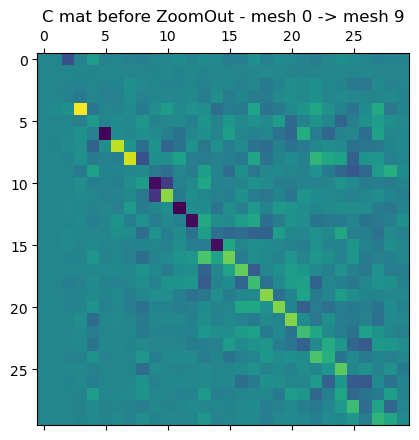

(43158, 3)
(39739, 3)
(39739,)


In [31]:
ind_1 = 0
ind_2 = 9

n_map = new_dict[(ind_1,ind_2)]
print(f"original map shape: {n_map.shape}")

plt.matshow(n_map)
plt.title(f"C mat before ZoomOut - mesh {ind_1} -> mesh {ind_2}")
plt.show()

# Test Display
mesh_1 = mesh_list_o3d[ind_1]; mesh_2 = mesh_list_o3d[ind_2]
verts_1 = np.asarray(mesh_1.vertices)
verts_2 = np.asarray(mesh_2.vertices)

p2p_map = initial_p2p_map(verts_2,verts_1)
cmap_1 = visu(verts_1)
cmap_2 = cmap_1[p2p_map]

print(verts_1.shape)
print(verts_2.shape)
print(p2p_map.shape)

double_plot_o3d(mesh_1, mesh_2, cmap_1,cmap_2)

original map shape: (30, 30)


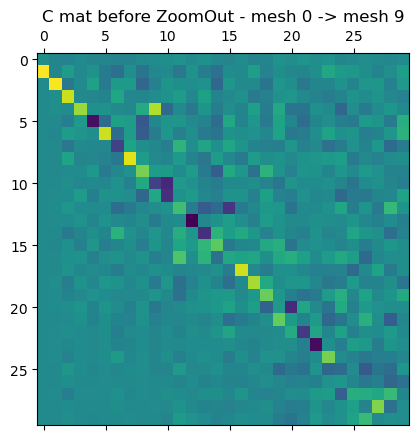

In [32]:
ind_1 = 0
ind_2 = 9

o_map = maps_dict[(ind_1,ind_2)]
print(f"original map shape: {o_map.shape}")

plt.matshow(o_map)
plt.title(f"C mat before ZoomOut - mesh {ind_1} -> mesh {ind_2}")
plt.show()

# Test Display
mesh_1 = mesh_list_o3d[ind_1]; mesh_2 = mesh_list_o3d[ind_2]
verts_1 = np.asarray(mesh_1.vertices)
verts_2 = np.asarray(mesh_2.vertices)

p2p_map = initial_p2p_map(verts_2,verts_1)
cmap_1 = visu(verts_1)
cmap_2 = cmap_1[p2p_map]

# print(verts_1.shape)
# print(verts_2.shape)
# print(p2p_map.shape)

double_plot_o3d(mesh_1, mesh_2, cmap_1,cmap_2)

In [ ]:
# map_1_2 = maps_dict[(0,1)]
# map_2_3 = maps_dict[(1,2)]
# map_3_4 = maps_dict[(2,3)]
# map_4_5 = maps_dict[(3,4)]

# map_5_6 = maps_dict[(4,5)]
# map_6_7 = maps_dict[(5,6)]
# map_7_8 = maps_dict[(6,7)]
# map_8_9 = maps_dict[(7,8)]
# map_9_10 = maps_dict[(8,9)]

# comp_map_1_10 = map_1_2 @ map_2_3 @ map_3_4 @ map_4_5 @ map_5_6 @ map_6_7 @ map_7_8 @ map_8_9 @ map_9_10

# maps_dict[(0,9)] = comp_map_1_10

## 2. Consistent Zoomout _______________________________________________
1. Create Functional Map Network (FMN)
2. Run ConsistentZoomout refinement
3. Visualise Results by converting refined maps back to point to point maps

In [45]:
from pyFM.FMN import FMN

# Build the network
fmn_model = FMN(mesh_list, maps_dict.copy())

Setting 90 edges on 10 nodes.


new map shape: (30, 30)


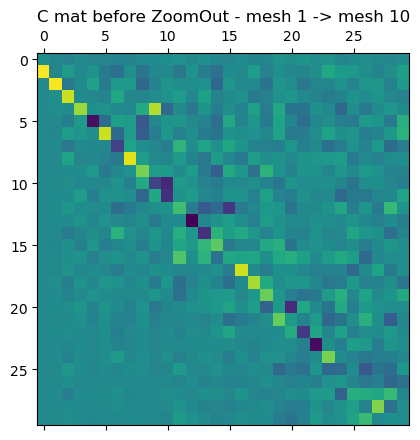

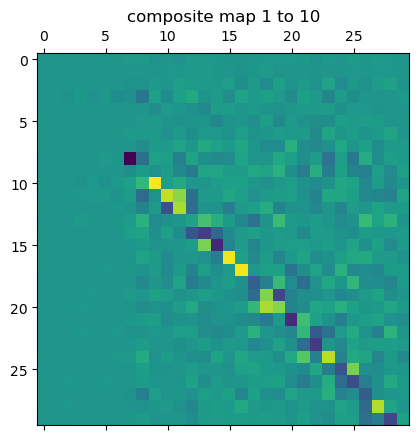

In [39]:
# add composite maps for missing edges?
ind_1 = 0
ind_2 = 9

mesh1, mesh2 = mesh_list[ind_1], mesh_list[ind_2]

new_maps_dict = fmn_model.maps
map_1_10 = new_maps_dict[(ind_1, ind_2)]

print(f"new map shape: {map_1_10.shape}")

plt.matshow(map_1_10)
plt.title(f"C mat before ZoomOut - mesh {ind_1+1} -> mesh {ind_2+1}")
plt.show()

map_1_2 = new_maps_dict[(0,1)]
map_2_3 = new_maps_dict[(1,2)]
map_3_4 = new_maps_dict[(2,3)]
map_4_5 = new_maps_dict[(3,4)]

map_5_6 = new_maps_dict[(4,5)]
map_6_7 = new_maps_dict[(5,6)]
map_7_8 = new_maps_dict[(6,7)]
map_8_9 = new_maps_dict[(7,8)]
map_9_10 = new_maps_dict[(8,9)]

comp_map_1_10 = map_1_2 @ map_2_3 @ map_3_4 @ map_4_5 @ map_5_6 @ map_6_7 @ map_7_8 @ map_8_9 @ map_9_10
plt.matshow(comp_map_1_10)
plt.title(f"composite map 1 to 10")
plt.show()




In [47]:
def sequence_adjacency(n_meshes,
                       decay='exp',
                       scale=1.0,
                       power=2.0,
                       sigma=1.0,
                       max_hop=None,
                       normalize='none'):
    """
    Build an n x n symmetric adjacency matrix where weight = f(|i-j|).

    Parameters
    ----------
    n_meshes : int
        Number of meshes in the sequence (indexed 0..n_meshes-1).
    decay : {'exp','inv','gauss','linear'}
        Decay type:
          - 'exp'   : exp(-scale * dist)
          - 'inv'   : 1 / (1 + (dist**power))
          - 'gauss' : exp(- (dist**2) / (2 * sigma**2))
          - 'linear': max(0, 1 - scale * dist)
    scale : float
        Controls decay rate for 'exp' and slope for 'linear'.
    power : float
        Power for 'inv' decay.
    sigma : float
        Sigma for Gaussian decay.
    max_hop : int or None
        If set, zero out weights for |i-j| > max_hop (sparse local connectivity).
    normalize : {'none','row','global'}
        - 'none'  : no normalization
        - 'row'   : row-normalize so each row sums to 1
        - 'global': divide by max weight so global max = 1

    Returns
    -------
    W : ndarray, shape (n_meshes, n_meshes)
        Symmetric adjacency weight matrix.
    """
    idx = np.arange(n_meshes)
    d = np.abs(idx[:, None] - idx[None, :]).astype(float)  # pairwise distances

    if decay == 'exp':
        W = np.exp(-scale * d)
    elif decay == 'inv':
        W = 1.0 / (1.0 + (d ** power))
    elif decay == 'gauss':
        W = np.exp(-(d ** 2) / (2.0 * sigma ** 2))
    elif decay == 'linear':
        W = np.maximum(0.0, 1.0 - scale * d)
    else:
        raise ValueError("decay must be one of 'exp','inv','gauss','linear'")

    # optionally mask out self or preserve (commonly keep self = 1)
    # W[np.diag_indices_from(W)] = 1.0  # usually fine to keep

    if max_hop is not None:
        W[d > max_hop] = 0.0

    # normalization
    if normalize == 'row':
        row_sums = W.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1.0
        W = W / row_sums
    elif normalize == 'global':
        maxv = W.max()
        if maxv > 0:
            W = W / maxv

    return W

size = len(mesh_list)
weights = sequence_adjacency(size)

fmn_model.set_weights(weights)

In [48]:
# Run Consistent Zoomout
fmn_model.compute_CCLB(m=20)
fmn_model.zoomout_refine(nit=25, step=2, subsample=3000, isometric=True, weight_type='adjacency',
                    M_init=None, cclb_ratio=.9, n_jobs=1, equals_id=False,
                    verbose=True)

Computing 30 CLB eigenvectors...
	Done in 0.0s
Computing a 3000-sized subsample for each mesh


  0%|          | 0/24 [00:00<?, ?it/s]

In [10]:
# To Save or Load Model
import pickle as p

# #save
with open("../../fmn_model_10.pkl", "wb") as f:
    p.dump(fmn_model, f)

# load
# with open("../../fmn_model_10.pkl", "rb") as f:
#     fmn_model = p.load(f)

# 3. Evaulate Model Perfromance and Results _____________________ [not working]

Computing 78 CLB eigenvectors...
	Done in 0.1s


Text(0.5, 1.0, 'Conformal CSD')

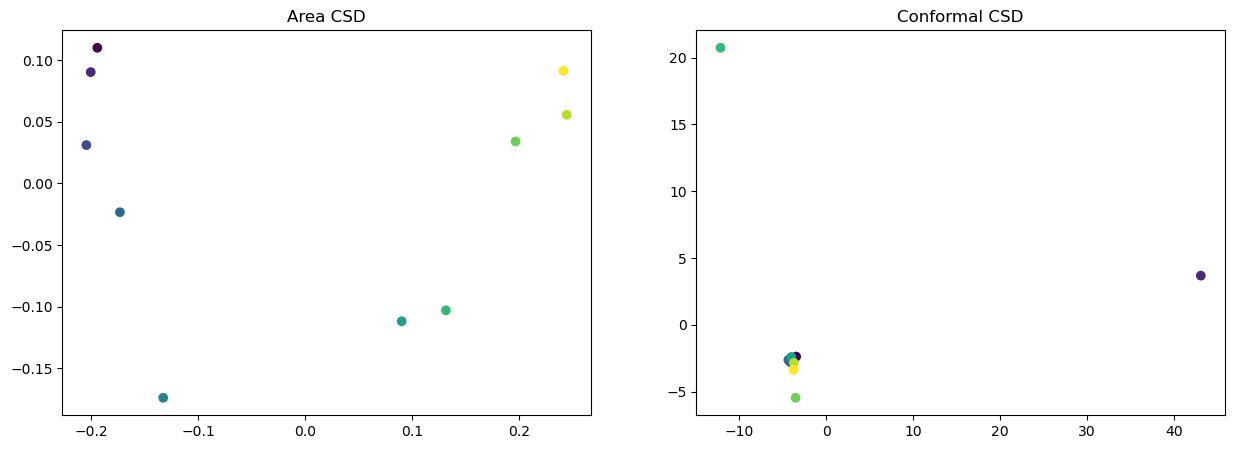

In [49]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

fmn_model.compute_CCLB(m=int(0.9*fmn_model.M))
fmn_model.cclb_eigenvalues.shape
all_embs_a = []
all_embs_c = []

for i in range(fmn_model.n_meshes):
    CSD_a, CSD_c = fmn_model.get_CSD(i)

    all_embs_a.append(CSD_a.flatten())
    all_embs_c.append(CSD_c.flatten())

all_embs_a = np.array(all_embs_a)
all_embs_c = np.array(all_embs_c)

pca_model = PCA(n_components=2)
emb_red_a = pca_model.fit_transform(all_embs_a)
emb_red_c = pca_model.fit_transform(all_embs_c)

_, axs = plt.subplots(1, 2, figsize=(15, 5))

axs[0].scatter(emb_red_a[:, 0], emb_red_a[:, 1], c=np.arange(len(emb_red_a)))
axs[0].set_title('Area CSD')

axs[1].scatter(emb_red_c[:, 0], emb_red_c[:, 1], c=np.arange(len(emb_red_c)))
axs[1].set_title('Conformal CSD')

# RUN THIS FOR VIS

new map shape: (78, 78)


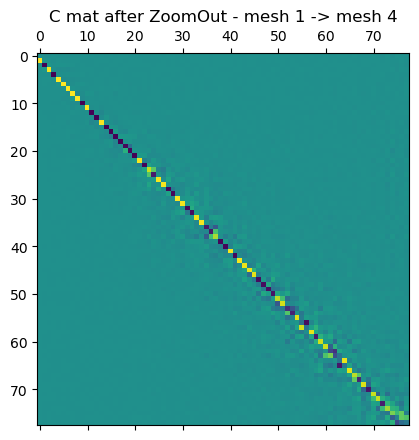

In [51]:
# For Display
ind_1 = 0
ind_2 = 3

mesh1, mesh2 = mesh_list[ind_1], mesh_list[ind_2]

new_maps_dict = fmn_model.maps
map_1_3 = new_maps_dict[(ind_1, ind_2)]

print(f"new map shape: {map_1_3.shape}")

plt.matshow(map_1_3)
plt.title(f"C mat after ZoomOut - mesh {ind_1+1} -> mesh {ind_2+1}")
plt.show()

# map_1_2 = new_maps_dict[(0,1)]
# map_2_3 = new_maps_dict[(1,2)]
# map_3_4 = new_maps_dict[(2,3)]
# map_4_5 = new_maps_dict[(3,4)]

# map_5_6 = new_maps_dict[(4,5)]
# map_6_7 = new_maps_dict[(5,6)]
# map_7_8 = new_maps_dict[(6,7)]
# map_8_9 = new_maps_dict[(7,8)]
# map_9_10 = new_maps_dict[(8,9)]

# comp_map = map_1_2 @ map_2_3 @ map_3_4 @ map_4_5 @ map_5_6 @ map_6_7 @ map_7_8 @ map_8_9 @ map_9_10
# plt.matshow(comp_map)
# plt.title(f"composite map 1 to 10")
# plt.show()


# mesh1_o3d, mesh2_o3d = mesh_list_o3d[ind_1], mesh_list_o3d[ind_2]
# verts_o3d = np.asarray(mesh1_o3d.vertices)

p2p_15 = spectral.convert.mesh_FM_to_p2p(map_1_3, mesh1, mesh2) # need to look at this function properly

cmap_1 = visu(mesh1.vertlist)
cmap_2 = cmap_1[p2p_15]
double_plot(mesh1, mesh2, cmap_1, cmap_2)

# print(mesh1.vertlist.shape)
# print(mesh2.vertlist.shape)
# print(p2p_21.shape)
